# Grad-CAM Explainability for Industrial Defect Classification

This notebook applies Grad-CAM to the trained MobileNetV2 baseline model.

The goal is to visualize which regions of the steel surface images influenced the model's prediction for the binary classification task:

- No Defect
- Defect

Grad-CAM is used to support model transparency and provide an initial explainability layer for industrial visual inspection.

In [13]:
import numpy as np
import sys

print(sys.executable)
print(sys.version)

c:\Users\user_1\AppData\Local\Programs\Python\Python313\python.exe
3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]


In [1]:
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.14.1


## 1. Load the Trained Model

In this step, the trained MobileNetV2 baseline model is loaded from the `models/` folder.

The model was previously trained for binary steel surface defect classification:

- `0` = No Defect
- `1` = Defect

In [2]:
from pathlib import Path

# Project root is one level above the notebooks folder
PROJECT_ROOT = Path("..")

MODEL_PATH = PROJECT_ROOT / "models" / "mobilenetv2_baseline.keras"

print("Model path:", MODEL_PATH)
print("Model exists:", MODEL_PATH.exists())

Model path: ..\models\mobilenetv2_baseline.keras
Model exists: True


In [3]:
# Load the trained MobileNetV2 baseline model

model = keras.models.load_model(MODEL_PATH)

print("Model loaded successfully!")
model.summary()

Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,829 (8.63 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2,564 (10.02 KB)

## 2. Inspect the MobileNetV2 Backbone

Grad-CAM needs the output of a convolutional layer.  
Since the model is a Sequential model that contains MobileNetV2 as a nested backbone, we first inspect the layers inside the MobileNetV2 feature extractor.

In [4]:
# Inspect the nested MobileNetV2 backbone

base_model = model.get_layer("mobilenetv2_1.00_224")

print("Base model name:", base_model.name)
print("Number of layers in base model:", len(base_model.layers))

# Print the last 20 layers to identify the final convolutional layer
for layer in base_model.layers[-20:]:
    print(layer.name, "->", layer.output.shape)

Base model name: mobilenetv2_1.00_224
Number of layers in base model: 154
block_15_expand -> (None, 7, 7, 960)
block_15_expand_BN -> (None, 7, 7, 960)
block_15_expand_relu -> (None, 7, 7, 960)
block_15_depthwise -> (None, 7, 7, 960)
block_15_depthwise_BN -> (None, 7, 7, 960)
block_15_depthwise_relu -> (None, 7, 7, 960)
block_15_project -> (None, 7, 7, 160)
block_15_project_BN -> (None, 7, 7, 160)
block_15_add -> (None, 7, 7, 160)
block_16_expand -> (None, 7, 7, 960)
block_16_expand_BN -> (None, 7, 7, 960)
block_16_expand_relu -> (None, 7, 7, 960)
block_16_depthwise -> (None, 7, 7, 960)
block_16_depthwise_BN -> (None, 7, 7, 960)
block_16_depthwise_relu -> (None, 7, 7, 960)
block_16_project -> (None, 7, 7, 320)
block_16_project_BN -> (None, 7, 7, 320)
Conv_1 -> (None, 7, 7, 1280)
Conv_1_bn -> (None, 7, 7, 1280)
out_relu -> (None, 7, 7, 1280)


## 3. Define the Grad-CAM Function

Grad-CAM uses the gradients of the model prediction with respect to the final convolutional feature maps.

The result is a heatmap that highlights the image regions that contributed most to the model's decision.

In [5]:
# Grad-CAM configuration

LAST_CONV_LAYER_NAME = "Conv_1"

# Get the MobileNetV2 backbone from the full Sequential model
base_model = model.get_layer("mobilenetv2_1.00_224")

# Create a model that returns:
# 1. the output of the last convolutional layer
# 2. the final output of the MobileNetV2 backbone
last_conv_layer = base_model.get_layer(LAST_CONV_LAYER_NAME)

base_grad_model = keras.Model(
    inputs=base_model.input,
    outputs=[last_conv_layer.output, base_model.output]
)

print("Grad-CAM layer:", LAST_CONV_LAYER_NAME)
print("Last conv output shape:", last_conv_layer.output.shape)

Grad-CAM layer: Conv_1
Last conv output shape: (None, 7, 7, 1280)


In [6]:
def make_gradcam_heatmap(img_array, model, base_grad_model, explain_class="predicted"):
    """
    Generate a Grad-CAM heatmap for a binary classification model.

    Parameters
    ----------
    img_array : np.ndarray
        Preprocessed image array with shape (1, 224, 224, 3).
    model : keras.Model
        Full trained model.
    base_grad_model : keras.Model
        Model that returns last conv layer output and base model output.
    explain_class : str
        "predicted", "defect", or "no_defect".

    Returns
    -------
    heatmap : np.ndarray
        Grad-CAM heatmap normalized between 0 and 1.
    pred_prob : float
        Predicted probability for the Defect class.
    predicted_label : str
        Predicted class label.
    """

    with tf.GradientTape() as tape:
        # Forward pass through MobileNetV2 backbone
        conv_outputs, base_outputs = base_grad_model(img_array)

        # Forward pass through the classification head
        x = model.get_layer("global_average_pooling2d")(base_outputs)
        x = model.get_layer("dropout")(x, training=False)
        preds = model.get_layer("dense")(x)

        # Binary sigmoid output: probability of Defect
        defect_prob = preds[:, 0]

        if explain_class == "defect":
            class_score = defect_prob
        elif explain_class == "no_defect":
            class_score = 1.0 - defect_prob
        else:
            # Explain the predicted class
            class_score = tf.where(defect_prob >= 0.5, defect_prob, 1.0 - defect_prob)

    # Gradients of class score with respect to conv feature maps
    grads = tape.gradient(class_score, conv_outputs)

    # Average gradients spatially to get channel importance weights
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the convolutional feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU and normalize between 0 and 1
    heatmap = tf.maximum(heatmap, 0)

    max_value = tf.reduce_max(heatmap)
    if max_value == 0:
        heatmap = heatmap
    else:
        heatmap = heatmap / max_value

    pred_prob = float(defect_prob.numpy()[0])
    predicted_label = "Defect" if pred_prob >= 0.5 else "No Defect"

    return heatmap.numpy(), pred_prob, predicted_label

## 4. Load and Preprocess Sample Images

In this step, sample steel surface images are loaded from the local dataset folder.

Each image is resized to 224 × 224 and preprocessed using the same MobileNetV2 preprocessing function used during training.

In [7]:
# Image loading and preprocessing utilities

from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)

TRAIN_IMAGES_DIR = PROJECT_ROOT / "data" / "raw" / "train_images"

print("Train images path:", TRAIN_IMAGES_DIR)
print("Train images folder exists:", TRAIN_IMAGES_DIR.exists())

Train images path: ..\data\raw\train_images
Train images folder exists: True


In [8]:
# Check a few available image files

image_paths = sorted(list(TRAIN_IMAGES_DIR.glob("*.jpg")))

print("Number of training images found:", len(image_paths))
print("First 5 image paths:")

for path in image_paths[:5]:
    print(path.name)

Number of training images found: 12568
First 5 image paths:
0002cc93b.jpg
00031f466.jpg
000418bfc.jpg
000789191.jpg
0007a71bf.jpg


## 5. Run Predictions on Sample Images

Before generating Grad-CAM heatmaps, a few sample images are passed through the trained model to check their predicted class and defect probability.

In [9]:
# Select a few sample images

sample_paths = image_paths[:6]

print("Selected sample images:")
for path in sample_paths:
    print(path.name)

Selected sample images:
0002cc93b.jpg
00031f466.jpg
000418bfc.jpg
000789191.jpg
0007a71bf.jpg
000a4bcdd.jpg


In [10]:
def load_and_preprocess_image(img_path, img_size=IMG_SIZE):
    """
    Load an image from disk and preprocess it for MobileNetV2.
    """
    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img)

    # Add batch dimension: (224, 224, 3) -> (1, 224, 224, 3)
    img_array_expanded = np.expand_dims(img_array, axis=0)

    # Apply MobileNetV2 preprocessing
    img_preprocessed = preprocess_input(img_array_expanded)

    return img, img_preprocessed

In [14]:
# Predict selected sample images

for img_path in sample_paths:
    original_img, img_array = load_and_preprocess_image(img_path)

    pred_prob = float(model.predict(img_array, verbose=0)[0][0])
    pred_label = "Defect" if pred_prob >= 0.5 else "No Defect"

    print(f"{img_path.name} | Prediction: {pred_label} | Defect probability: {pred_prob:.4f}")

0002cc93b.jpg | Prediction: Defect | Defect probability: 0.8131
00031f466.jpg | Prediction: No Defect | Defect probability: 0.3563
000418bfc.jpg | Prediction: No Defect | Defect probability: 0.3152
000789191.jpg | Prediction: No Defect | Defect probability: 0.0576
0007a71bf.jpg | Prediction: Defect | Defect probability: 0.7566
000a4bcdd.jpg | Prediction: Defect | Defect probability: 0.5026


## 5. Prediction Interpretation

For each sample image, the model outputs a **defect probability**, which represents how likely the image is to belong to the **Defect** class.

The binary decision rule is:

- If `defect probability >= 0.5` → the image is classified as **Defect**
- If `defect probability < 0.5` → the image is classified as **No Defect**

This means that the model does not directly output only a class label.  
Instead, it first produces a probability score, and the final class is determined using a threshold of **0.5**.

For example:

- A probability of `0.8131` means the model is quite confident that the image contains a defect.
- A probability of `0.0576` means the model is quite confident that the image does **not** contain a defect.
- A probability close to `0.5`, such as `0.5026`, indicates a more uncertain or borderline prediction.

This interpretation is useful in industrial quality control, because borderline cases may require additional review or future threshold tuning to better balance false positives and false negatives.

## 6. Generate and Visualize Grad-CAM Heatmaps

In this step, Grad-CAM heatmaps are generated for the selected sample images.

The heatmap highlights the regions of the image that contributed most to the model's prediction.

Red/yellow regions indicate stronger contribution to the prediction, while darker regions indicate lower contribution.

In [15]:
# Grad-CAM visualization utility

import matplotlib.pyplot as plt

def overlay_gradcam(original_img, heatmap, alpha=0.4):
    """
    Overlay a Grad-CAM heatmap on top of the original image.

    Parameters
    ----------
    original_img : PIL.Image
        Original image loaded with target size.
    heatmap : np.ndarray
        Grad-CAM heatmap with values between 0 and 1.
    alpha : float
        Heatmap transparency factor.

    Returns
    -------
    superimposed_img : np.ndarray
        Image with Grad-CAM heatmap overlay.
    """

    # Convert PIL image to numpy array
    img_array = np.array(original_img).astype("uint8")

    # Resize heatmap to image size
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (img_array.shape[0], img_array.shape[1])
    ).numpy()

    heatmap_resized = np.squeeze(heatmap_resized)

    # Convert heatmap to RGB using a colormap
    colormap = plt.cm.jet
    heatmap_colored = colormap(heatmap_resized)[:, :, :3]
    heatmap_colored = np.uint8(255 * heatmap_colored)

    # Overlay heatmap on original image
    superimposed_img = heatmap_colored * alpha + img_array
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

    return superimposed_img

In [16]:
# Generate Grad-CAM for one sample image

test_img_path = sample_paths[0]

original_img, img_array = load_and_preprocess_image(test_img_path)

heatmap, pred_prob, pred_label = make_gradcam_heatmap(
    img_array=img_array,
    model=model,
    base_grad_model=base_grad_model,
    explain_class="predicted"
)

overlay_img = overlay_gradcam(original_img, heatmap)

print("Image:", test_img_path.name)
print("Prediction:", pred_label)
print("Defect probability:", round(pred_prob, 4))

Image: 0002cc93b.jpg
Prediction: Defect
Defect probability: 0.8131


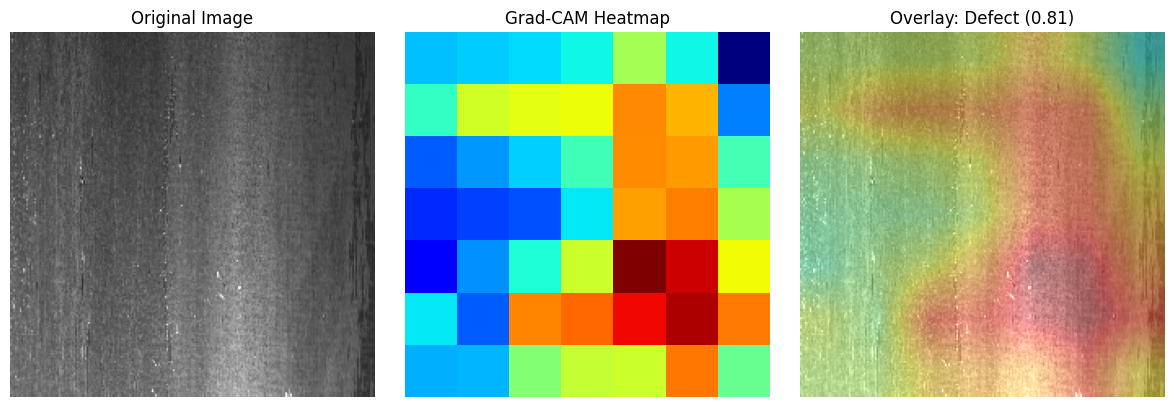

In [17]:
# Display original image, heatmap, and Grad-CAM overlay

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_img)
plt.title(f"Overlay: {pred_label} ({pred_prob:.2f})")
plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Generate Grad-CAM Examples for Multiple Images

The same Grad-CAM process is applied to multiple sample images.

For each image, the notebook displays:

- the original image
- the Grad-CAM overlay
- the predicted class
- the defect probability

The final figure is saved in the `results/` folder so it can be used in the README, CV, LinkedIn, or project documentation.

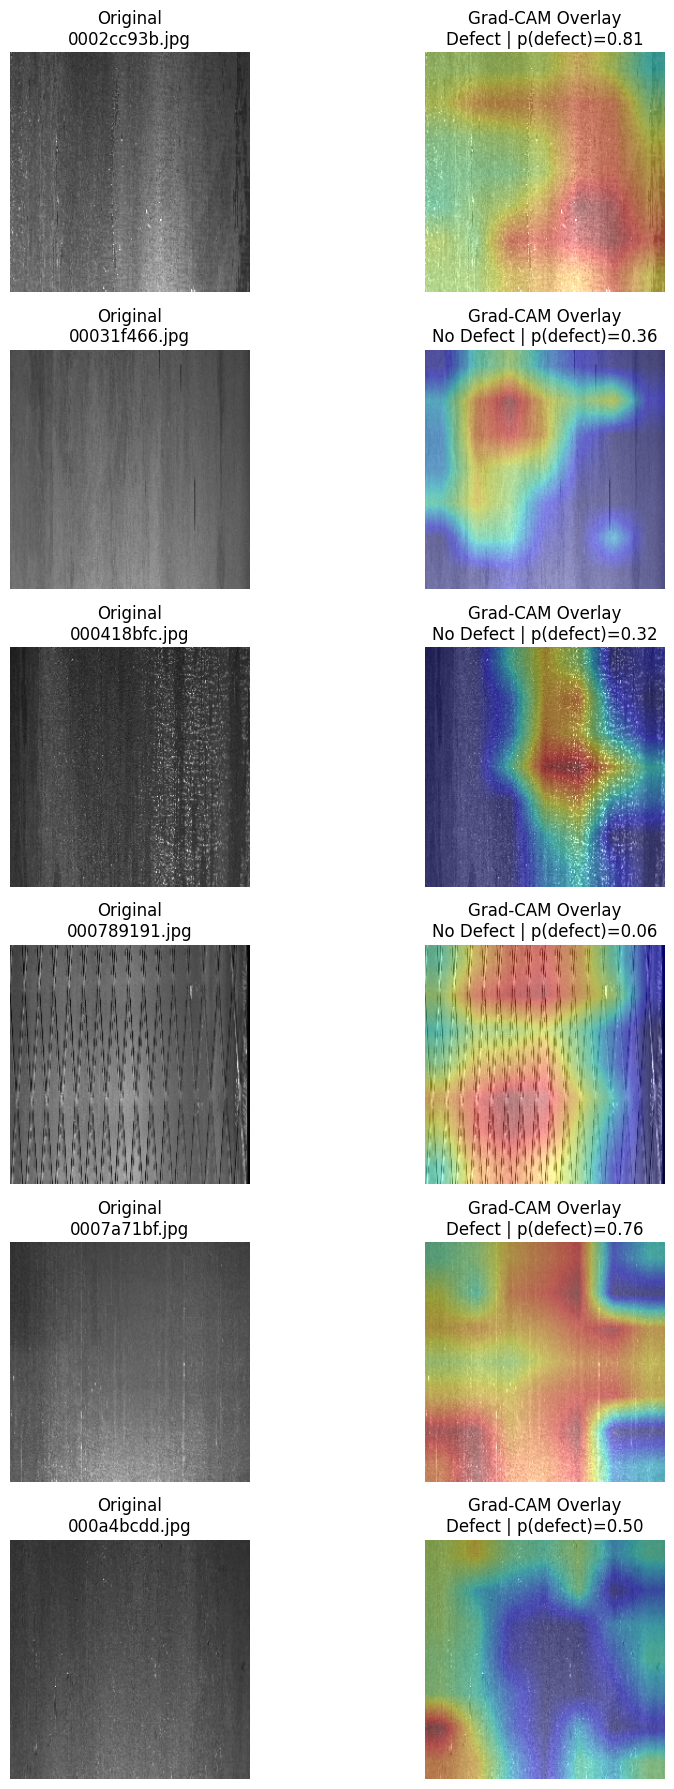

In [18]:
# Generate Grad-CAM overlays for multiple sample images

num_examples = 6
sample_paths = image_paths[:num_examples]

fig, axes = plt.subplots(num_examples, 2, figsize=(10, 3 * num_examples))

for i, img_path in enumerate(sample_paths):
    original_img, img_array = load_and_preprocess_image(img_path)

    heatmap, pred_prob, pred_label = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        base_grad_model=base_grad_model,
        explain_class="predicted"
    )

    overlay_img = overlay_gradcam(original_img, heatmap)

    # Original image
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Original\n{img_path.name}")
    axes[i, 0].axis("off")

    # Grad-CAM overlay
    axes[i, 1].imshow(overlay_img)
    axes[i, 1].set_title(f"Grad-CAM Overlay\n{pred_label} | p(defect)={pred_prob:.2f}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 8. Save Grad-CAM Results

The generated Grad-CAM examples are saved in the `results/` folder.

This output can be used later in the GitHub README, project documentation, CV/LinkedIn portfolio presentation, or thesis-related material.

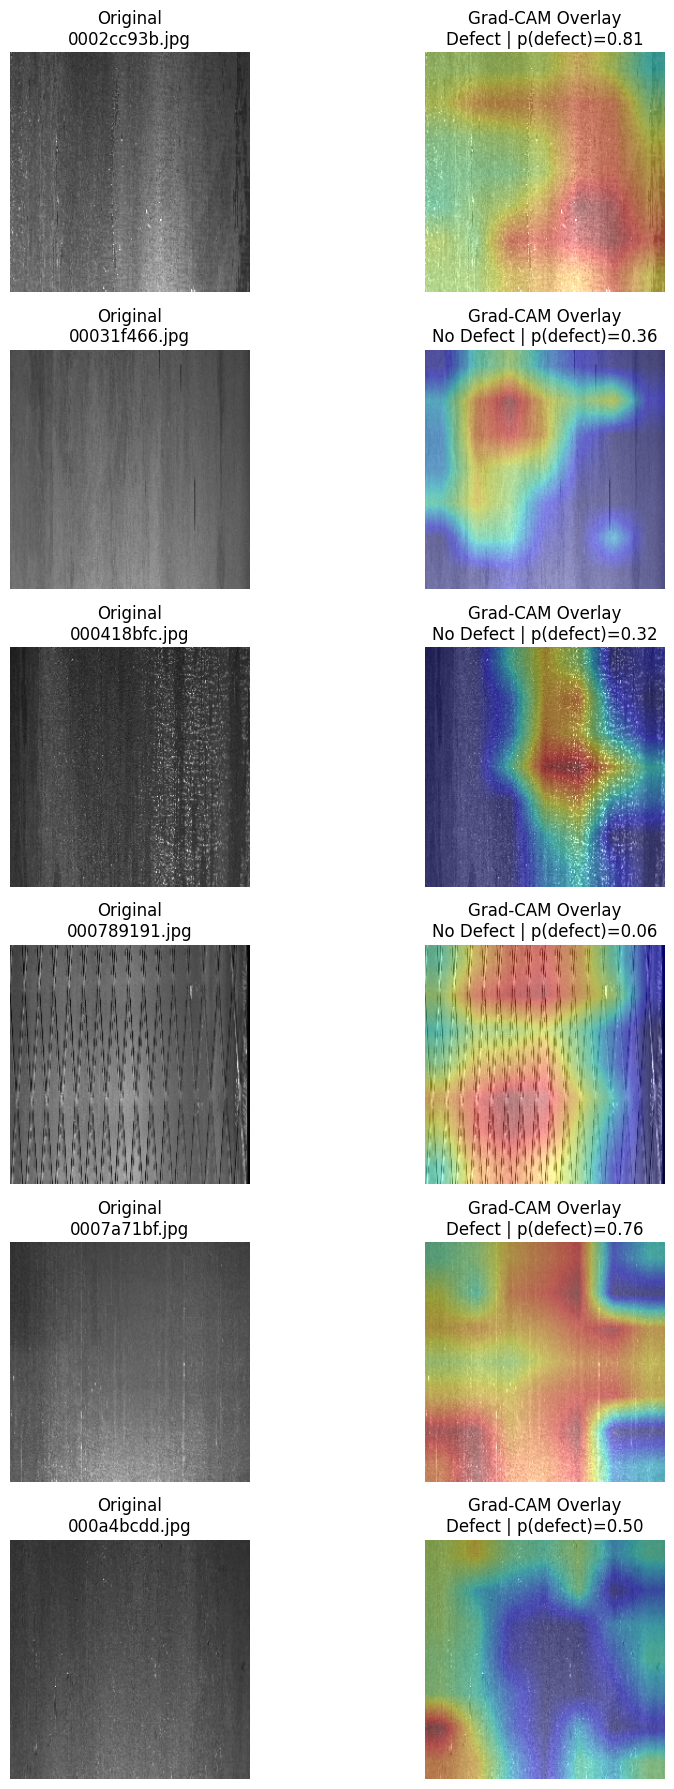

Grad-CAM figure saved to:
..\results\gradcam_examples.png


In [19]:
# Save Grad-CAM examples figure

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

output_path = RESULTS_DIR / "gradcam_examples.png"

num_examples = 6
sample_paths = image_paths[:num_examples]

fig, axes = plt.subplots(num_examples, 2, figsize=(10, 3 * num_examples))

for i, img_path in enumerate(sample_paths):
    original_img, img_array = load_and_preprocess_image(img_path)

    heatmap, pred_prob, pred_label = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        base_grad_model=base_grad_model,
        explain_class="predicted"
    )

    overlay_img = overlay_gradcam(original_img, heatmap)

    # Original image
    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Original\n{img_path.name}")
    axes[i, 0].axis("off")

    # Grad-CAM overlay
    axes[i, 1].imshow(overlay_img)
    axes[i, 1].set_title(f"Grad-CAM Overlay\n{pred_label} | p(defect)={pred_prob:.2f}")
    axes[i, 1].axis("off")

plt.tight_layout()
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Grad-CAM figure saved to:")
print(output_path)

## 9. Interpretation of the Grad-CAM Results

The Grad-CAM visualizations provide an initial explanation of the model's predictions.

Some observations from these examples:

- The model tends to focus on specific texture or surface regions when making a prediction.
- In images predicted as **Defect**, the highlighted regions may indicate areas that contain suspicious visual patterns.
- In images predicted as **No Defect**, the attention may still appear distributed across textured regions of the surface.
- Some heatmaps are broad and low-resolution, which is expected because Grad-CAM is generated from the final convolutional feature maps of size `7 × 7`.

This means that Grad-CAM does not provide pixel-level localization, but rather a coarse indication of which image regions influenced the model most.

Overall, these visualizations help assess whether the model is focusing on meaningful regions instead of irrelevant background patterns.

## 10. Limitations of the Current Explainability Step

This Grad-CAM analysis is an initial explainability step and has some limitations:

- The heatmaps are coarse because they are based on low-resolution feature maps.
- The model is trained for **binary classification**, not for defect localization or segmentation.
- A highlighted region does not necessarily mean that the model has precisely localized the defect.
- More explainability methods could be explored in future work, such as Grad-CAM++, Score-CAM, Integrated Gradients, or comparisons with true defect masks.

Despite these limitations, Grad-CAM is useful as a first interpretability tool for understanding model attention in industrial visual inspection.